In [2]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#set main paths
CUR_DIR = os.path.dirname(os.path.abspath(__name__))
print(CUR_DIR)
DATA_DIR = CUR_DIR+'/data/human_annotation/'


/Users/anna/Dropbox/2023_AOI/MoralLearning/CodeSets/graph_extract


In [4]:
scenario = 1
choice = 1

### some function definitions for analysis

In [6]:
def compute_reliability(value_data):
    """
    Compute inter-rater reliability using correlation.
    
    Parameters:
    value_data (DataFrame): DataFrame containing annotator scores.
    
    Returns:
    float: Mean correlation between annotators.
    """
    # Select columns starting with 'p' for annotator scores
    annotator_columns = [col for col in value_data.columns if col.startswith('p')]
    annotator_data = value_data[annotator_columns].values
    
    # Compute all pairwise correlations
    correlations = np.corrcoef(annotator_data, rowvar=False)
    
    # Take the upper triangle of the correlation matrix
    upper_triangle_indices = np.triu_indices_from(correlations, k=1)
    
    # Extract the upper triangle values
    upper_triangle_values = correlations[upper_triangle_indices]
    
    # Take the mean of the upper triangle values
    mean_correlation = np.mean(upper_triangle_values)


    print(f"Mean correlation between raters: {mean_correlation:.2f}")
    
    return mean_correlation


In [67]:
def calc_binary_agreement(rater_data):
    """
    Calculate the binary agreement between raters.
    
    Parameters:
    links_data (DataFrame): DataFrame containing rater data.
    
    Returns:
    float: Mean binary agreement across all rows.
    """

    agreement_data = []

    for idx,this_row in rater_data.iterrows():

        n = len(this_row)
        agreement_0 = sum(this_row==0)
        agreement_1 = sum(this_row==1) 
        agreement = abs(agreement_0-agreement_1) / n
        agreement_data.append(agreement)
        # print(f"Row {idx} has {agreement_0} 0s and {agreement_1} 1s out of {n} total ratings.")
        # print(f"Agreement for row {idx}: {agreement:.2f}")

    mean_agreement = np.mean(agreement_data)
    print(f"Mean binary agreement across all raters: {mean_agreement:.3f}")
    return(mean_agreement)

### Value Scores

##### show the data

In [7]:
filename_value_scores = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_value_scores.csv"
value_data = pd.read_csv(filename_value_scores, usecols=lambda column: column != 'Unnamed: 0')
value_data
#figures are already saved in the Results folder

,value_names,annotator_scores,p1,p2,p3,p4,p5,p6,p8,mean,se_mean,mean_dist,se_mean_dist,mean_abs_dist,values_missing
0,loyalty,80,76,4,45,90,61,23,70,52.714286,12.489361,-27.285714,12.489361,30.142857,"pity,pity,yes he is a liar,Pity,Lack of courage"
1,compassion,90,73,19,100,90,89,93,70,76.285714,11.209406,-13.714286,11.209406,17.428571,"pity,pity,yes he is a liar,Pity,Lack of courage"
2,supportiveness,90,82,90,81,100,100,84,70,86.714286,4.426651,-3.285714,4.426651,9.000000,"pity,pity,yes he is a liar,Pity,Lack of courage"
3,empathy,80,74,82,100,100,79,100,75,87.142857,5.024543,7.142857,5.024543,10.571429,"pity,pity,yes he is a liar,Pity,Lack of courage"
4,commitment,80,61,10,80,61,53,59,70,56.285714,9.060642,-23.714286,9.060642,23.714286,"pity,pity,yes he is a liar,Pity,Lack of courage"
5,kindness,90,20,37,90,90,74,91,70,67.428571,11.546662,-22.571429,11.546662,22.857143,"pity,pity,yes he is a liar,Pity,Lack of courage"
6,responsibility,70,22,23,78,100,78,29,60,55.714286,12.794778,-14.285714,12.794778,27.428571,"pity,pity,yes he is a liar,Pity,Lack of courage"
7,neglect,0,97,86,0,0,29,8,10,32.857143,16.876066,32.857143,16.876066,32.857143,"pity,pity,yes he is a liar,Pity,Lack of courage"
8,indifference,0,85,82,0,0,56,21,30,39.142857,14.625755,39.142857,14.625755,39.142857,"pity,pity,yes he is a liar,Pity,Lack of courage"
9,selfishness,0,100,95,11,18,59,11,20,44.857143,16.147632,44.857143,16.147632,44.857143,"pity,pity,yes he is a liar,Pity,Lack of courage"


#### report inter-rater agreement and correlation with annotator

In [8]:
#report overall correlation between annotator_scores and mean
correlation = np.corrcoef(value_data['annotator_scores'], value_data['mean'])[0, 1]
print(f"Correlation between annotator scores and mean scores: {correlation:.2f}")
compute_reliability(value_data)
#compute the mean absolute distance by taking the mean in the value_data
print(f"Mean absolute distance from annotator scores: {np.mean(value_data['mean_abs_dist']):.2f}")

Correlation between annotator scores and mean scores: 0.80
Mean correlation between raters: 0.21
Mean absolute distance from annotator scores: 25.80


### Outcome Likelihood Ratings

In [9]:
filename_outcome_scores = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_outcomes.csv"
outcome_data = pd.read_csv(filename_outcome_scores, usecols=lambda column: column != 'Unnamed: 0')
outcome_data

,outcome,p1,p2,p3,p4,p5,p6,p8,mean,se_mean
0,I continue to provide financial support for li...,100,81,78,100,20,87,75,77.285714,11.089821
1,I continue to assist with transportation to sc...,100,73,83,100,19,68,80,74.714286,11.214362
2,I continue to do the majority of the cooking.,83,97,77,80,58,72,80,78.142857,4.804099
3,My girlfriend continues to rely on me for supp...,100,87,76,90,31,87,90,80.142857,9.301818
4,My girlfriend may delay becoming fully indepen...,19,100,67,95,63,70,80,70.571429,10.905802
5,I may experience ongoing feelings of guilt.,100,100,100,100,100,88,90,96.857143,2.203893
6,My girlfriend remains unaware of my true feeli...,100,77,31,100,26,92,80,72.285714,12.751284
7,My relationship continues without a future com...,82,100,100,10,70,74,80,73.714286,12.431399


In [10]:
print(f"Mean ratings (100 is correct): {np.mean(outcome_data['mean']):.2f}")

Mean ratings (100 is correct): 77.96


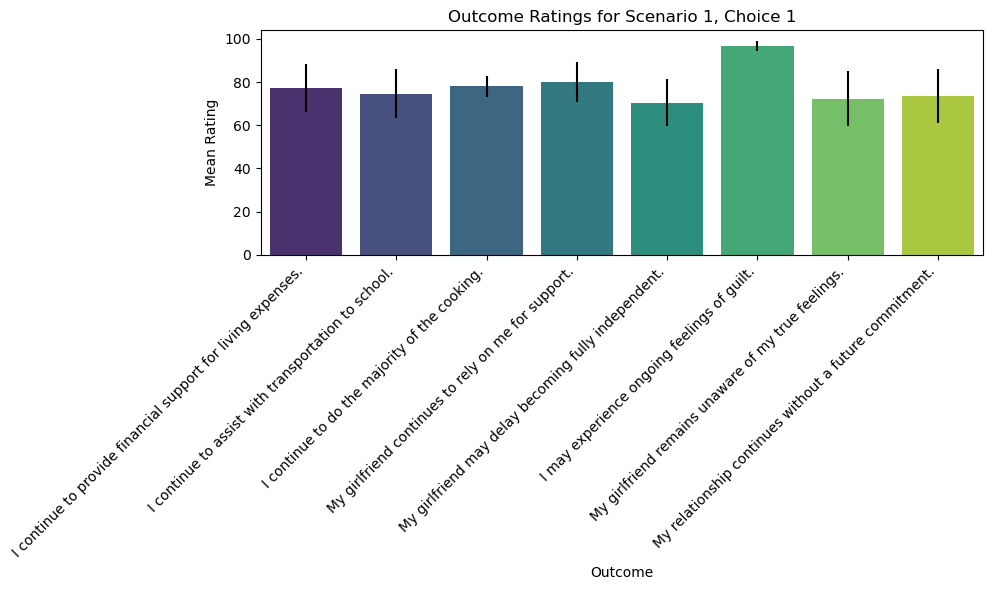

In [10]:
#select only mean and se_mean columns
outcome_data_simple = outcome_data[['outcome','mean', 'se_mean']]

#plot the outcome data using outcome as the x-axis and mean as the y-axis, with se_mean as the error bars
#add a legend for the x axis labels along the right side of the plot
plt.figure(figsize=(10, 6))
sns.barplot(x='outcome', y='mean', data=outcome_data_simple, yerr=outcome_data_simple['se_mean'], capsize=0.1, palette='viridis')
plt.xlabel('Outcome')
plt.ylabel('Mean Rating')
plt.xticks(rotation=45, ha='right')
plt.title(f'Outcome Ratings for Scenario {scenario}, Choice {choice}')
plt.tight_layout()
plt.show()

### Outcome Utilities

In [11]:
filename_util_scores = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_outcome_utilities.csv"
util_data = pd.read_csv(filename_util_scores, usecols=lambda column: column != 'Unnamed: 0')
util_data

,annot_scores,p1,p2,p3,p4,p5,p6,p8,entity,outcome,subj_means,subj_se
0,-30,-100,61,-42,-100,-100,-34,-20,I,I continue to provide financial support for li...,-47.857143,24.157387
1,80,100,42,63,100,100,74,75,my girlfriend,I continue to provide financial support for li...,79.142857,9.111740
2,20,-100,46,-25,-100,-70,-33,-30,I,I continue to assist with transportation to sc...,-44.571429,20.899039
3,0,100,24,27,100,-74,69,75,my girlfriend,I continue to assist with transportation to sc...,45.857143,24.970459
4,-30,-64,-53,-25,-80,26,-49,-50,I,I continue to do the majority of the cooking.,-42.142857,14.018695
5,50,82,-85,0,100,-40,77,75,my girlfriend,I continue to do the majority of the cooking.,29.857143,29.279713
6,0,-100,62,-31,-100,-13,-43,-20,I,My girlfriend continues to rely on me for supp...,-35.000000,22.759613
7,50,100,64,49,100,-15,62,60,my girlfriend,My girlfriend continues to rely on me for supp...,60.000000,15.781494
8,0,-80,-100,-100,-100,-34,-53,0,I,My girlfriend may delay becoming fully indepen...,-66.714286,15.994295
9,-20,36,-100,-100,-100,-36,-20,-40,my girlfriend,My girlfriend may delay becoming fully indepen...,-51.428571,21.132988


In [12]:
#turn util_data into long format with annot_scores and subj_means combined into a columne called "rating" and their respective columns as "type"; include columns 'entity' and 'subj_se'
util_data_long = pd.melt(util_data, id_vars=['outcome', 'entity', 'subj_se'], value_vars=['annot_scores', 'subj_means'], 
                         var_name='type', value_name='rating')

#where type is annot_scores, set subj_se to 0
util_data_long.loc[util_data_long['type'] == 'annot_scores', 'subj_se'] = 0

/var/folders/4g/x09k0pjs3lv174fn9g0511840000gn/T/ipykernel_18307/3494948160.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='outcome', y='rating', hue='type', data=plot_data, ci=None, capsize=0.1, palette='magma')


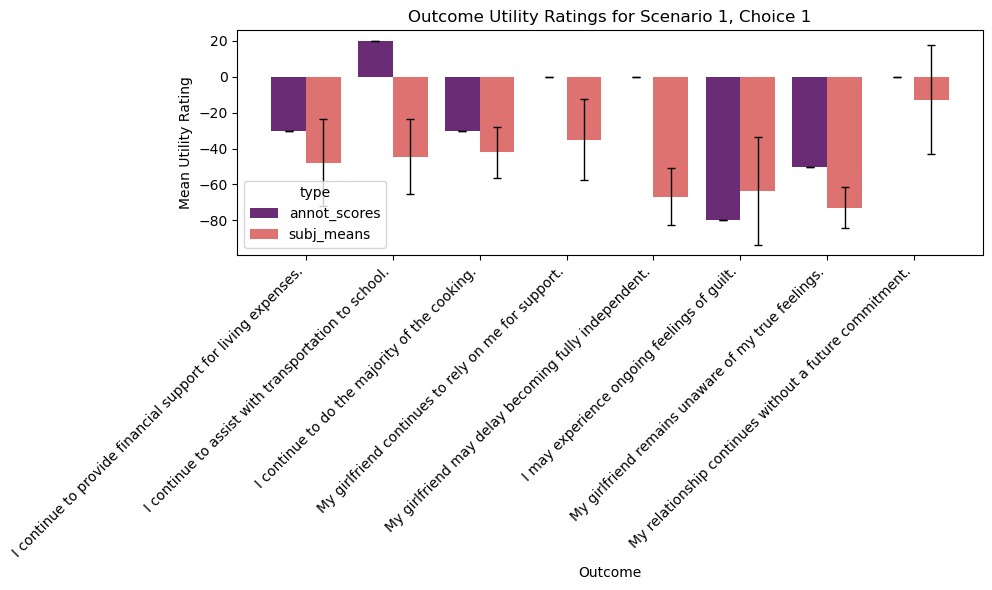

In [13]:
#select an entity to plot--here selecting just the first
entity_names = util_data_long['entity'].unique()
plot_data = util_data_long[util_data_long['entity'] == entity_names[0]]
#create a bar plot of the outcome ratings with separate bars for each entity, and using subj_means as the y-axis and subj_se as the error bars

plt.figure(figsize=(10, 6))


#pair the bars so that the first bar is the annotator score and the second bar is the subject mean
ax = sns.barplot(x='outcome', y='rating', hue='type', data=plot_data, ci=None, capsize=0.1, palette='magma')

# Add error bars manually
for i, (bar, (_, row)) in enumerate(zip(ax.patches, plot_data.iterrows())):
	# Get the bar position
	x = bar.get_x() + bar.get_width() / 2
	y = bar.get_height()
	err = row['subj_se']
	ax.errorbar(x, y, yerr=err, fmt='none', c='black', capsize=3, linewidth=1)

plt.xlabel('Outcome')
plt.ylabel('Mean Utility Rating')
plt.xticks(rotation=45, ha='right')
plt.title(f'Outcome Utility Ratings for Scenario {scenario}, Choice {choice}')
plt.tight_layout()
plt.show()

In [69]:
correlation = np.corrcoef(util_data['annot_scores'], util_data['subj_means'])[0, 1]
print(f"Correlation between annotator scores and mean scores: {correlation:.2f}")
mean_agree = compute_reliability(util_data)

Correlation between annotator scores and mean scores: 0.78
Mean correlation between raters: 0.43


### Outcome Links

In [72]:
filename_links = f"{DATA_DIR}scenarios_{scenario}_choice_{choice}_outcome_links.csv"
links_data = pd.read_csv(filename_links, usecols=lambda column: column != 'Unnamed: 0')
links_data

,outcome_name,link_type,annot_links,p1,p2,p3,p4,p5,p6,p8,subj_mean,agreement_percentage,subj_se
0,I continue to provide financial support for li...,Cause,1,0,1,1,0,1,1,1,0.714286,0.714286,0.199205
1,I continue to provide financial support for li...,Intend,1,0,0,0,0,1,1,0,0.285714,0.285714,0.199205
2,I continue to provide financial support for li...,Expect,1,0,0,1,1,1,1,1,0.714286,0.714286,0.199205
3,I continue to assist with transportation to sc...,Cause,1,0,0,1,1,1,0,1,0.571429,0.571429,0.218218
4,I continue to assist with transportation to sc...,Intend,1,0,0,0,0,1,1,1,0.428571,0.428571,0.218218
5,I continue to assist with transportation to sc...,Expect,1,0,0,1,0,1,1,1,0.571429,0.571429,0.218218
6,I continue to do the majority of the cooking.,Cause,1,1,0,1,1,0,1,1,0.714286,0.714286,0.199205
7,I continue to do the majority of the cooking.,Intend,1,0,1,0,0,0,0,1,0.285714,0.285714,0.199205
8,I continue to do the majority of the cooking.,Expect,1,1,0,1,0,0,1,1,0.571429,0.571429,0.218218
9,My girlfriend continues to rely on me for supp...,Cause,1,1,0,0,1,1,0,1,0.571429,0.571429,0.218218


In [75]:
#computer mean agreement between raters
# Select columns starting with 'p' for rater data
rater_data = links_data.filter(regex='^p', axis=1)
mean_agree_ = calc_binary_agreement(rater_data)

#print the mean agreement with annotator
mean_agreement_annot = np.mean(links_data['agreement_percentage'])
print(f"Mean agreement with annotator: {mean_agreement_annot:.2f}")

Mean binary agreement across all raters: 0.286
Mean agreement with annotator: 0.58


In [77]:
#select one link type to plot

links_data_cause = links_data[links_data['link_type'] == 'Cause']
links_data_cause_simple = links_data_cause[['outcome_name', 'subj_mean', 'subj_se', 'annot_links']]
#convert links_data_cause to long format with annot_links and subj_mean combined into a column called "rating" and their respective columns as "type"; include columns 'outcome_name' and 'subj_se'
links_data_cause_long = pd.melt(links_data_cause, id_vars=['outcome_name', 'subj_se'], 
                                 value_vars=['annot_links', 'subj_mean'], 
                                 var_name='type', value_name='rating')
#where type is annot_links, set subj_se to 0
links_data_cause_long.loc[links_data_cause_long['type'] == 'annot_links', 'subj_se'] = 0


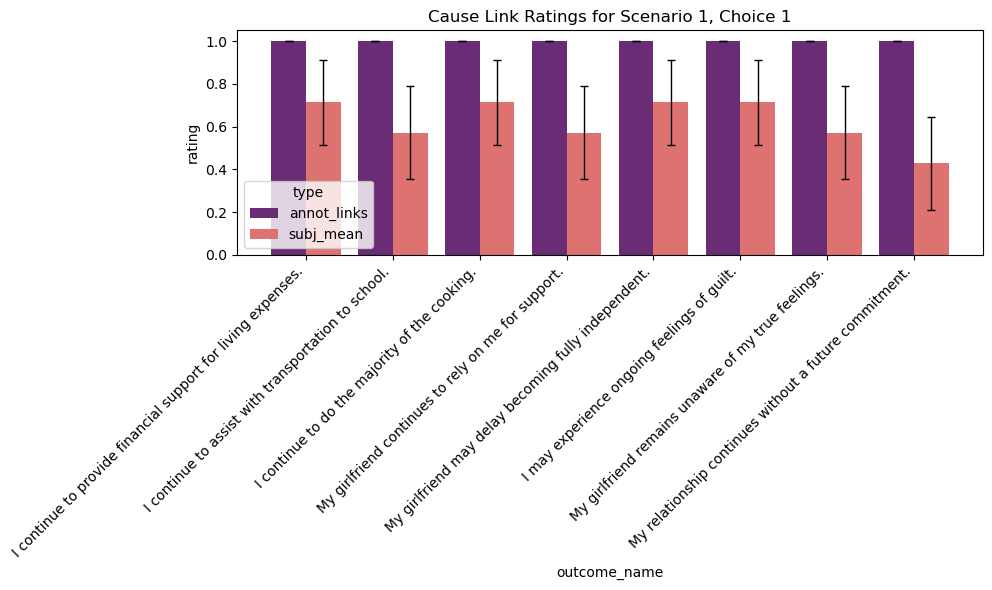

In [82]:
#select only the link types "cause" and make a plot showing subj_mean in a bar plot with error bars based on subj_se
#add a bar next to it showing the value of annot_links

plt.figure(figsize=(10, 6))
ax=sns.barplot(x='outcome_name', y='rating', hue='type', data=links_data_cause_long, errorbar=None, capsize=2, palette='magma')

# Add error bars manually
for i, (bar, (_, row)) in enumerate(zip(ax.patches, links_data_cause_long.iterrows())):
	# Get the bar position
	x = bar.get_x() + bar.get_width() / 2
	y = bar.get_height()
	err = row['subj_se']
	ax.errorbar(x, y, yerr=err, fmt='none', c='black', capsize=3, linewidth=1)

plt.xticks(rotation=45, ha='right')
plt.title(f'Cause Link Ratings for Scenario {scenario}, Choice {choice}')
plt.tight_layout()
plt.show()